# Problem 1

In [ ]:
import torch
import torch.utils.data as data 
import torch.nn as nn
from torch.distributions.normal import Normal 
from torch.distributions.uniform import Uniform
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import warnings 
warnings.filterwarnings("ignore")

In [ ]:
epochs = 1000
learning_rate = 5e-3
batch_size = 128
n_components=5 # the number of kernel
target_distribution = Normal(0.0, 1.0)

In [ ]:
#####################################
# STEP 1: Implement 1-d Flow model  #
# Model is misture of Gaussian CDFs #
#####################################

class Flow1d(nn.Module):
    def __init__(self, n_components):
        super(Flow1d, self).__init__()
        self.mus = nn.Parameter(torch.randn(n_components), requires_grad=True)
        self.log_sigmas = nn.Parameter(torch.zeros(n_components), requires_grad=True)
        self.weight_logits = nn.Parameter(torch.ones(n_components), requires_grad=True)

    def forward(self, x):
        x = x.view(-1,1)
        # implement this
        weights = self.weight_logits.exp().view(1,-1)
        distribution = Normal(self.mus, self.log_sigmas.exp())
        z = ((distribution.cdf(x)-0.5) * weights).sum(dim=1)
        dz_by_dx = (distribution.log_prob(x).exp() * weights).sum(dim=1)
        return z, dz_by_dx

In [ ]:
################################################
# STEP 2: Create Dataset and Create Dataloader #
################################################ 

def mixture_of_gaussians(num, mu_var=(-1,0.25, 0.2,0.25, 1.5,0.25)):
    n = num // 3
    m1,s1,m2,s2,m3,s3 = mu_var
    gaussian1 = np.random.normal(loc=m1, scale=s1, size=(n,))
    gaussian2 = np.random.normal(loc=m2, scale=s2, size=(n,))
    gaussian3 = np.random.normal(loc=m3, scale=s3, size=(num-n,))
    return np.concatenate([gaussian1, gaussian2, gaussian3])

class MyDataset(data.Dataset):
    def __init__(self, array):
        super().__init__()
        self.array = array

    def __len__(self):
        return len(self.array)

    def __getitem__(self, index):
        return self.array[index]


In [ ]:
################################
# STEP 3: Define Loss Function #
################################
def loss_function(target_distribution, z, dz_by_dx):
    # log(p_Z(z)) = target_distribution.log_prob(z)
    # log(dz/dx) = dz_by_dx.log() (flow is defined so that dz/dx>0)
    log_likelihood = target_distribution.log_prob(z) + dz_by_dx.log()
    return -log_likelihood.mean()  #flip sign, and sum of data X_1,...X_N

In [ ]:
###########################
# STEP 4: Train the model #
########################### 

# create dataloader
n_train, n_test = 5000, 1000
train_data = mixture_of_gaussians(n_train)
test_data = mixture_of_gaussians(n_test)

train_loader = data.DataLoader(MyDataset(train_data), batch_size=batch_size, shuffle=True)
test_loader = data.DataLoader(MyDataset(test_data), batch_size=batch_size, shuffle=True)

# create model
flow = Flow1d(n_components)
optimizer = torch.optim.Adam(flow.parameters(), lr=learning_rate)

train_losses, test_losses = [], []

for epoch in range(epochs):
    # train
#     flow.train()
    mean_loss = 0
    for i, x in enumerate(train_loader):
        z, dz_by_dx = flow(x)
        loss = loss_function(target_distribution, z, dz_by_dx)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        mean_loss += loss.item()
    train_losses.append(mean_loss/(i+1))

    # test
    flow.eval()
    mean_loss = 0
    for i, x in enumerate(test_loader):
        z, dz_by_dx = flow(x)
        loss = loss_function(target_distribution, z, dz_by_dx)

        mean_loss += loss.item()
    test_losses.append(mean_loss/(i+1))

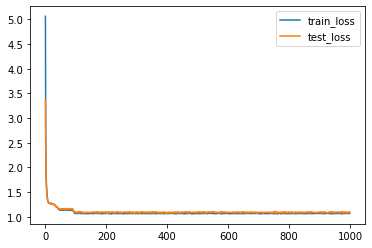

In [ ]:
plt.plot(train_losses, label='train_loss')
plt.plot(test_losses, label='test_loss')
plt.legend()

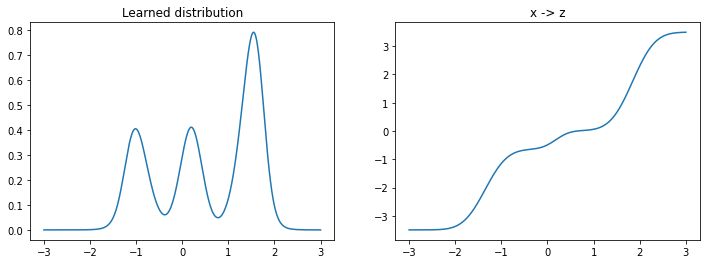

In [ ]:
x = np.linspace(-3,3,1000)
with torch.no_grad():
    z, dz_by_dx = flow(torch.FloatTensor(x))
    px = (target_distribution.log_prob(z) + dz_by_dx.log()).exp().cpu().numpy()
    
_, axes = plt.subplots(1,2, figsize=(12,4))
_ = axes[0].plot(x,px)
_ = axes[0].set_title('Learned distribution')

_ = axes[1].plot(x,z)
_ = axes[1].set_title('x -> z')

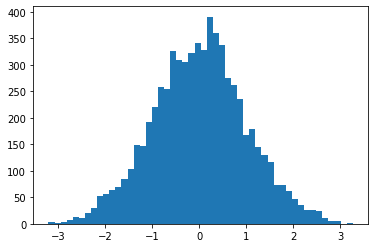

In [ ]:
with torch.no_grad():
    z, _ = flow(torch.FloatTensor(train_loader.dataset.array))
    
_ = plt.hist(np.array(z), bins=50)

# Problem 6

In [1]:
N = 3000
K = 600
p = 18/37
q = 0.55

In [2]:
import torch

In [3]:
arr = torch.ones(N,K)
arr = torch.bernoulli(arr*q) # 600차원 벡터 * 3000개

In [16]:
def phi(X):
  pos = 100
  for i in range(len(X)):
    pos += 2*X[i]-1
    if pos>=200:
      return 1
    elif pos<=0:
      return 0
  return 0

def f(X):
  return torch.pow(p,X.sum().double())*torch.pow(1-p,(K-X.sum()).double())

def g(X):
  return torch.pow(q,X.sum().double())*torch.pow(1-q,(K-X.sum()).double())

In [17]:
print(f(arr[1,:]))
print(g(arr[1,:]))
print(phi(arr[1,:]))

tensor(4.4958e-182, dtype=torch.float64)
tensor(2.6645e-180, dtype=torch.float64)
0


In [18]:
s = torch.mean(torch.tensor([f(arr[i,:]) / g(arr[i, :]) * phi(arr[i, :]) for i in range(N)]))

In [21]:
print(f"probability : {s.tolist()}")

probability : 2.2059165179411235e-06


# Problem 7

*(a) the log-derivative trick*

In [ ]:
import torch
import math
import numpy as np

mu = 0
tau = 0
lr = 1e-2
B = 25
iterations = 2000  # not epochs, iterations
history1 = torch.zeros((iterations+1),2)

history1[0][1] = 1

for itr in range(iterations):
    X = torch.normal(mu,np.exp(tau),size=(B,))
    g = torch.sum(X*torch.sin(X)*(X-mu)* (np.exp(-2*tau)))/B + mu - 1
    h = torch.sum(X*torch.sin(X)*((X-mu)**2 * np.exp(-2*tau) -1))/B + np.exp(tau) -1
    mu -= lr*g
    tau -= lr*h
    # save history
    history1[itr+1][0] = mu
    history1[itr+1][1] = np.exp(tau)
    
print(f"mu : {mu.tolist()}, sigma : {np.exp(tau.tolist())}")

mu : 0.4355337619781494, sigma : 0.5916807390900852


*(b) the reparameterisation trick*

In [ ]:
import torch
import math
import numpy as np

mu = 0
tau = 0
lr = 1e-2
B = 25
iterations = 2000  # not epochs, iterations
history2 = torch.zeros((iterations+1, 2))

history2[0][1] = 1

for itr in range(iterations):
    Y = torch.normal(0,1,size=(B,))
    g = torch.sum((np.exp(tau)*Y+mu)*torch.cos(np.exp(tau)*Y+mu)+torch.sin(np.exp(tau)*Y+mu))/B + mu - 1
    h = torch.sum(((np.exp(tau)*Y+mu)*torch.cos(np.exp(tau)*Y+mu)+torch.sin(np.exp(tau)*Y+mu))*np.exp(tau)*Y)/B + np.exp(tau) - 1
    mu -= lr*g
    tau -= lr*h
    # save history
    history2[itr+1][0] = mu
    history2[itr+1][1] = np.exp(tau)
  
print(f"mu : {mu.tolist()}, sigma : {np.exp(tau.tolist())}")

mu : 0.42898011207580566, sigma : 0.607804746827791


*compare*

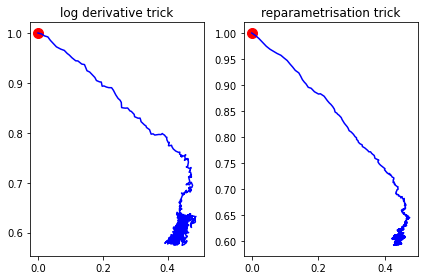

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

x1 = np.array(history1[:, 0])
y1 = np.array(history1[:, 1])

x2 = np.array(history2[:, 0])
y2 = np.array(history2[:, 1])

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.scatter(0,1, s=100, c='red')
ax1.plot(x1, y1, linestyle='solid',color='blue')
ax1.set_title('log derivative trick')

ax2.scatter(0,1, s=100, c='red')
ax2.plot(x2, y2, linestyle='solid',color='blue')
ax2.set_title('reparametrisation trick')

plt.tight_layout()
#plt.savefig('derivative_trick.png')
plt.show()